# Porosity Feasibility Assessment

**Question:** Can non-destructive plasma-material interaction measurements (optical emission
spectroscopy, thermal imaging, electrical signals) predict electrode porosity, which is
currently only available through offline/destructive characterization?

**Data:** 20 electrode samples. Each sample has a reference `thickness` and `porosity`
value, plus 100 repeated in-process measurements. Each measurement is a snapshot of:
- 256-bin OES intensity spectrum (`OES_bin_0..255`)
- a 512-point voltage waveform (`V_t_0..511`)
- a 512-point current waveform (`I_t_0..511`)
- a flattened 1024-pixel thermal image (`IR_pix_0..1023`)

So the raw measurement table is 2000 rows (20 samples x 100 repeats) x 2304 sensor
features, but the *target* (porosity) only varies at the sample level — there are only
**20 independent porosity values** to learn from. That single fact drives every modeling
choice below: with n=20 and thousands of candidate features, the binding constraint is not
finding a model that fits, but finding out whether any signal here is real at all.

**Approach:** start from the simplest possible baseline (predict the mean), and make every
model beat that baseline under two independent cross-validation schemes before believing
it. Report the honest result, including when it's a negative one.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, LeaveOneOut, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA = Path("data")
plt.rcParams["figure.dpi"] = 110


## 1. Load data

In [2]:
sample_info = pd.read_csv(DATA / "Sample_Info.csv", index_col=0)

measurement_parts = [
    "Measurement_Data_part_1_samples_0-6.csv",
    "Measurement_Data_part_2_samples_7-13.csv",
    "Measurement_Data_part_3_samples_14-19.csv",
]
meas = pd.concat(
    [pd.read_csv(DATA / fn, index_col=0) for fn in measurement_parts],
    ignore_index=True,
)

oes_wavelengths = pd.read_csv(DATA / "OES_Wavelengths.csv", index_col=0)

feat_cols = [c for c in meas.columns if c not in ("sample_id", "measurement_id")]
oes_cols = [c for c in feat_cols if c.startswith("OES_bin")]
vt_cols = [c for c in feat_cols if c.startswith("V_t")]
it_cols = [c for c in feat_cols if c.startswith("I_t")]
ir_cols = [c for c in feat_cols if c.startswith("IR_pix")]

print(f"sample_info: {sample_info.shape}")
print(f"measurements: {meas.shape}  (OES={len(oes_cols)}, V_t={len(vt_cols)}, "
      f"I_t={len(it_cols)}, IR_pix={len(ir_cols)})")
sample_info.head()


sample_info: (20, 3)
measurements: (2000, 2306)  (OES=256, V_t=512, I_t=512, IR_pix=1024)


,sample_id,thickness,porosity
0,0,92.17,27.36
1,1,70.68,26.89
2,2,83.67,20.26
3,3,93.86,28.91
4,4,92.64,31.02


## 2. Data quality checks

Before trusting any model output, check the basics: is every sample represented the same
way, is anything missing, and how noisy are repeated measurements of the *same* sample?


In [3]:
counts = meas.groupby("sample_id").size()
id_ranges = meas.groupby("sample_id").measurement_id.agg(["min", "max", "nunique"])
n_missing = meas[feat_cols].isna().sum().sum()
n_dupes = meas.duplicated(subset=["sample_id", "measurement_id"]).sum()

print(f"samples: {meas.sample_id.nunique()} (expected 20)")
print(f"measurements per sample -> min={counts.min()}, max={counts.max()} (expected 100 each)")
print(f"missing values in sensor columns: {n_missing}")
print(f"duplicate (sample_id, measurement_id) rows: {n_dupes}")
assert set(meas.sample_id.unique()) == set(sample_info.sample_id.unique()), "sample_id mismatch between tables"


samples: 20 (expected 20)
measurements per sample -> min=100, max=100 (expected 100 each)
missing values in sensor columns: 0
duplicate (sample_id, measurement_id) rows: 0


In [4]:
# Within-sample repeatability: for each block, how much does a sample's 100 repeat
# measurements vary relative to their own spread? (median |std/mean| per sample, per block)
grp = meas.groupby("sample_id")
cv_rows = {}
for name, cols in [("OES_bin", oes_cols), ("V_t", vt_cols), ("I_t", it_cols), ("IR_pix", ir_cols)]:
    means = grp[cols].mean()
    stds = grp[cols].std()
    with np.errstate(divide="ignore", invalid="ignore"):
        cv_rows[name] = (stds.abs() / means.abs().replace(0, np.nan)).median(axis=1)
cv_df = pd.DataFrame(cv_rows)
cv_df.round(2)


,OES_bin,V_t,I_t,IR_pix
sample_id,,,,
0,2.01,0.03,0.68,0.02
1,1.43,0.03,0.17,2.48
2,0.87,0.03,0.61,0.37
3,1.43,0.03,0.16,0.20
4,1.95,0.03,0.68,0.02
5,1.43,0.03,0.12,0.01
6,1.95,0.03,0.61,1.29
7,1.97,0.03,0.67,0.01
8,1.98,0.03,0.80,0.02


No missing values, no duplicate measurement rows, and every sample has exactly 100
repeats — the raw data is clean. `V_t` has near-zero within-sample variability in this
median-CV view only because its per-timepoint *mean* is close to zero (it's an oscillating
waveform, not a steady level — see Section 8); that's a property of the signal, not a data
defect. Nothing here flags a specific sample as corrupted or a specific block as
unusable, so no rows are excluded going forward.


## 3. Aggregate to sample level

The porosity target exists once per sample, not once per measurement. To model it, each
sample's 100 repeat measurements are collapsed to one feature vector per sample (mean
across repeats). This is also the point where the effective sample size for everything
that follows becomes n=20.


In [5]:
sample_feats = grp[feat_cols].mean().reset_index()
data = sample_info.merge(sample_feats, on="sample_id", how="left").sort_values("sample_id").reset_index(drop=True)

assert data.shape[0] == 20
assert not data[feat_cols].isna().any().any()

y = data["porosity"].values
thickness = data["thickness"].values
X_full = data[feat_cols].values

print(f"sample-level table: {data.shape}")
data[["sample_id", "thickness", "porosity"]]


sample-level table: (20, 2307)


,sample_id,thickness,porosity
0,0,92.17,27.36
1,1,70.68,26.89
2,2,83.67,20.26
3,3,93.86,28.91
4,4,92.64,31.02
5,5,66.23,28.34
6,6,85.75,26.24
7,7,75.73,28.55
8,8,78.25,25.95
9,9,68.24,19.96


## 4. Exploratory data analysis

porosity: min=19.96 max=32.34 mean=27.00 std=3.24
thickness: min=66.17 max=98.74 mean=78.74 std=10.85
thickness vs porosity: r=+0.284, p=0.225


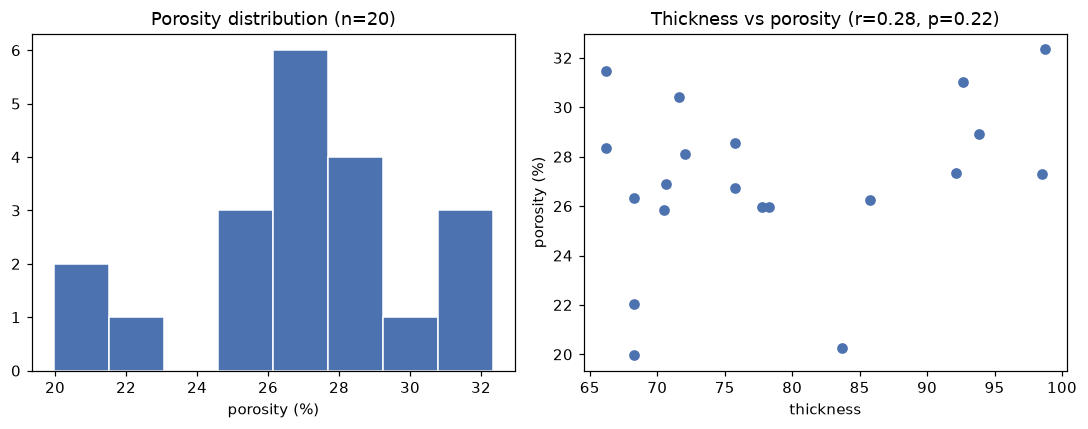

In [6]:
r_thick, p_thick = pearsonr(thickness, y)
print(f"porosity: min={y.min():.2f} max={y.max():.2f} mean={y.mean():.2f} std={y.std():.2f}")
print(f"thickness: min={thickness.min():.2f} max={thickness.max():.2f} mean={thickness.mean():.2f} std={thickness.std():.2f}")
print(f"thickness vs porosity: r={r_thick:+.3f}, p={p_thick:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(y, bins=8, color="#4C72B0", edgecolor="white")
axes[0].set_title("Porosity distribution (n=20)")
axes[0].set_xlabel("porosity (%)")

axes[1].scatter(thickness, y, color="#4C72B0")
axes[1].set_xlabel("thickness")
axes[1].set_ylabel("porosity (%)")
axes[1].set_title(f"Thickness vs porosity (r={r_thick:.2f}, p={p_thick:.2f})")
plt.tight_layout()
plt.show()


Porosity spans roughly 20-32% across the 20 samples — a real but not huge range relative
to typical measurement noise. Thickness has only a weak, not-significant correlation with
porosity (r≈0.28, p≈0.22), so it isn't a shortcut predictor on its own, but it's kept
as a candidate feature since it's a real physical measurement, not a sensor proxy.


## 5. Modeling framework

With 2,304 sensor features and 20 samples, the risk is not underfitting — it's finding a
model that looks predictive purely by chance. Three things are applied consistently
everywhere below to control that risk:

1. **A constant baseline (predict the training-fold mean porosity) is the bar every model
   must clear.** A model that doesn't beat guessing the mean isn't using the sensors.
2. **Two independent CV schemes** — 5-fold and leave-one-out (LOO) — must **both** show
   improvement over baseline before a result counts as a real finding. Either one alone,
   with n=20, is enough to be swayed by which samples fall in which fold.
3. **No leakage:** scaling, PCA components, and ridge's regularization strength are all
   fit *inside* each training fold only (via nested CV / `RidgeCV`'s internal LOO), never
   on the full dataset before splitting.

Two models are compared to the baseline:
- **Ridge regression** on standardized features, with the ridge penalty tuned via internal
  LOO CV on the training fold (`RidgeCV`).
- **PCR (principal component regression):** standardize, PCA, then linear regression on
  the top-k components, with k chosen by inner cross-validation on the training fold.


In [7]:
class MeanBaseline(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.mean_ = np.mean(y)
        return self

    def predict(self, X):
        return np.full(X.shape[0], self.mean_)


def make_ridge_pipeline():
    alphas = np.logspace(-2, 5, 40)
    return Pipeline([
        ("scale", StandardScaler()),
        ("ridge", RidgeCV(alphas=alphas, cv=None)),  # cv=None -> efficient internal LOO on the training fold
    ])


def make_pcr_pipeline(n_train):
    max_k = max(1, min(10, n_train - 2))
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(random_state=RANDOM_STATE)),
        ("lr", LinearRegression()),
    ])
    inner_cv = (KFold(n_splits=min(5, n_train), shuffle=True, random_state=RANDOM_STATE)
                if n_train >= 5 else LeaveOneOut())
    return GridSearchCV(pipe, param_grid={"pca__n_components": list(range(1, max_k + 1))},
                         scoring="neg_mean_absolute_error", cv=inner_cv)


def evaluate(X, y, scheme, model_name):
    n = len(y)
    cv = (KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) if scheme == "five_fold"
          else LeaveOneOut())
    preds = np.zeros(n)
    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        if model_name == "baseline":
            model = MeanBaseline()
        elif model_name == "ridge":
            model = make_ridge_pipeline()
        elif model_name == "pcr":
            model = make_pcr_pipeline(len(train_idx))
        else:
            raise ValueError(model_name)
        model.fit(X_train, y_train)
        preds[test_idx] = model.predict(X_test)
    return mean_absolute_error(y, preds), preds


## 6. Pass 1 — full sensor set (all 2,304 features)

The most direct thing to try first: throw every sensor feature at the models and see if
either beats the baseline.


In [8]:
pass1_rows = []
pass1_preds = {}
for scheme in ["five_fold", "loo"]:
    for model_name in ["baseline", "ridge", "pcr"]:
        mae, preds = evaluate(X_full, y, scheme, model_name)
        pass1_rows.append({"scheme": scheme, "model": model_name, "MAE": round(mae, 3)})
        pass1_preds[(scheme, model_name)] = preds

pass1_table = pd.DataFrame(pass1_rows).pivot(index="model", columns="scheme", values="MAE")
pass1_table = pass1_table.reindex(["baseline", "ridge", "pcr"])[["five_fold", "loo"]]
pass1_table


scheme,five_fold,loo
model,,
baseline,2.445,2.503
ridge,2.514,2.372
pcr,3.185,2.773


**Neither ridge nor PCR consistently beats the baseline across both schemes.** Ridge does
slightly better than baseline under LOO but worse under 5-fold; PCR is worse than baseline
under both. With 2,304 features competing for signal from 20 samples, this is the expected
outcome when there either isn't a strong linear relationship in the *full* feature set, or
it's swamped by noise features. This is not yet a "no" — it just means throwing everything
at the model isn't the way to find whatever signal exists. Next: look at whether any single
sensor *block* carries more signal than the full mixed set.


## 7. Pass 2 — each sensor block alone

Splitting the 2,304 features by physical origin (OES spectrum, voltage waveform, current
waveform, thermal image) and testing each block in isolation checks whether one sensor
type carries a real signal that gets diluted when mixed with the other three.


In [9]:
blocks = {"OES_bin": oes_cols, "V_t": vt_cols, "I_t": it_cols, "IR_pix": ir_cols}
pass2_rows = []
for bname, cols in blocks.items():
    Xb = data[cols].values
    for scheme in ["five_fold", "loo"]:
        for model_name in ["ridge", "pcr"]:
            mae, _ = evaluate(Xb, y, scheme, model_name)
            pass2_rows.append({"block": bname, "scheme": scheme, "model": model_name, "MAE": round(mae, 3)})

pass2_df = pd.DataFrame(pass2_rows)
pass2_table = pass2_df.pivot_table(index=["block", "model"], columns="scheme", values="MAE")
pass2_table = pass2_table.reindex(["OES_bin", "V_t", "I_t", "IR_pix"], level="block")[["five_fold", "loo"]]
baseline_row = pd.DataFrame(
    {"five_fold": [pass1_table.loc["baseline", "five_fold"]],
     "loo": [pass1_table.loc["baseline", "loo"]]},
    index=pd.MultiIndex.from_tuples([("baseline", "-")], names=["block", "model"]),
)
pd.concat([baseline_row, pass2_table])


five_fold    loo
block    model                  
baseline -          2.445  2.503
OES_bin  pcr        3.068  2.771
         ridge      2.983  2.467
V_t      pcr        3.093  2.501
         ridge      2.920  2.924
I_t      pcr        3.056  2.869
         ridge      3.001  2.654
IR_pix   pcr        2.499  2.114
         ridge      2.312  2.045

In [10]:
best_scores = pass2_df.pivot_table(index="block", columns="model", values="MAE")
beats_baseline = (pass2_df.assign(
        beats_baseline=lambda d: d.apply(
            lambda r: r.MAE < pass1_table.loc["baseline", r.scheme], axis=1)))
summary = beats_baseline.groupby("block")["beats_baseline"].sum()
print("configurations (of 4: ridge/pcr x five_fold/loo) that beat baseline, per block:")
print(summary)


configurations (of 4: ridge/pcr x five_fold/loo) that beat baseline, per block:
block
IR_pix     3
I_t        0
OES_bin    1
V_t        1
Name: beats_baseline, dtype: int64


**`IR_pix` (the thermal image block) with ridge is the only block/model pairing that beats
the baseline under *both* CV schemes** (2.312 vs. baseline 2.445 under 5-fold; 2.045 vs.
2.503 under LOO) — the one consistent result across this whole exploration. PCR on
`IR_pix` also beats baseline under LOO (2.114) but not 5-fold (2.499). `OES_bin`/ridge and
`V_t`/PCR each get a single, marginal win under LOO only (2.467 vs. 2.503, and 2.501 vs.
2.503 respectively) — differences that small, appearing in only one scheme with one model,
are consistent with noise rather than a real effect. `I_t` never beats baseline under
either scheme with either model. This points at the thermal signal as the most credible
lead, but "best of four blocks tried" is itself a form of the same multiple-comparisons
risk flagged again in Section 9 — it's a lead worth following up, not a confirmed finding
from this sample alone.


## 8. What do the voltage and thermal signals actually look like?

Before engineering features from the voltage and thermal blocks, it's worth looking at the
raw signal shape, since `V_t` and `I_t` are time-domain waveforms within a single
measurement, and `IR_pix` is a flattened spatial image, not a time series.

**Assumption, stated explicitly:** the `V_t_0..511` / `I_t_0..511` suffix is treated as a
time index within one measurement (there's no separate timestamp column to confirm this;
it's the natural reading of a 512-point "_t" array and it's consistent with how it looks
below — a smooth, periodic waveform, not noise).


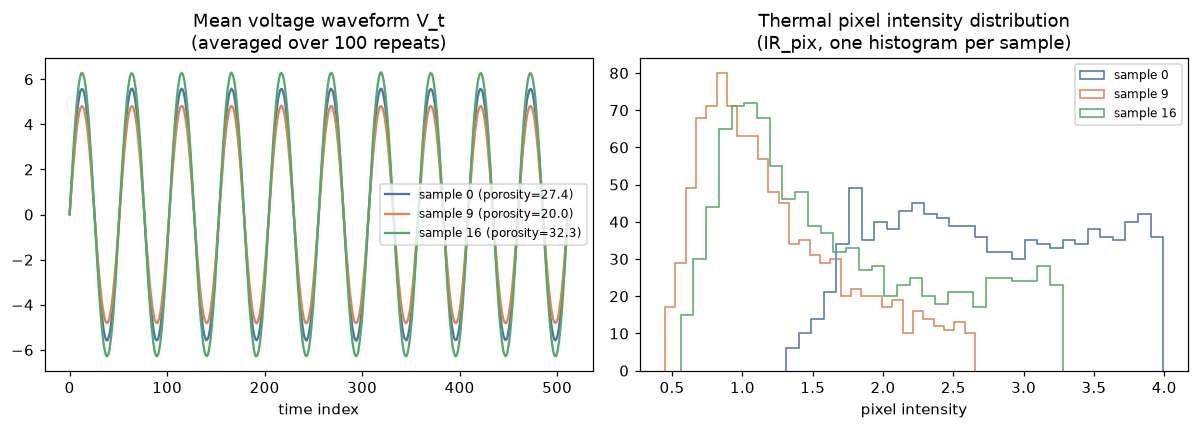

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
example_samples = [0, 9, 16]  # low, mid, high porosity examples
colors = ["#4C72B0", "#DD8452", "#55A868"]
t_idx = np.arange(len(vt_cols))

for sid, c in zip(example_samples, colors):
    row = grp.get_group(sid)[vt_cols].mean(axis=0).values
    axes[0].plot(t_idx, row, color=c, label=f"sample {sid} (porosity={y[sid]:.1f})")
axes[0].set_title("Mean voltage waveform V_t\n(averaged over 100 repeats)")
axes[0].set_xlabel("time index")
axes[0].legend(fontsize=8)

for sid, c in zip(example_samples, colors):
    row = grp.get_group(sid)[ir_cols].mean(axis=0).values
    axes[1].hist(row, bins=30, histtype="step", color=c, label=f"sample {sid}")
axes[1].set_title("Thermal pixel intensity distribution\n(IR_pix, one histogram per sample)")
axes[1].set_xlabel("pixel intensity")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


The voltage waveform is a clean, periodic oscillation whose *amplitude* visibly differs
between samples — a natural candidate feature. The thermal pixel distribution is a single
number per pixel per measurement (no time axis), so its natural summary statistics are
**level** (mean intensity) and **spread** (how much intensity varies across pixels within
one thermal image, e.g. std) rather than a waveform amplitude.


## 9. Engineered features (Pass 3)

Based on Sections 7-8, three physically-motivated summary features are built — one from
each of the two blocks that showed a lead, collapsing 2,304 raw features down to 3:

- **`voltage_amplitude`**: half the peak-to-peak range of the `V_t` waveform, per
  measurement, averaged over the 100 repeats.
- **`thermal_mean`**: mean thermal pixel intensity (`IR_pix`), a proxy for overall process
  heat level.
- **`thermal_amplitude`**: std of thermal pixel intensity within one image, a proxy for
  spatial hot-spot contrast.

**Important caveat on how these were chosen:** they were picked *because* Sections 7-8
showed `IR_pix` and `V_t` carrying more signal than `OES_bin`/`I_t` on this same 20-sample
set. That makes this a targeted, physically-motivated hypothesis — a real improvement over
guessing blindly — but a good result below is still a well-motivated hypothesis test on the
data that produced the hypothesis, not independent confirmation. That would require testing
on new samples not involved in choosing the features.


Pearson correlation with porosity (n=20):
  voltage_amplitude    r=+0.362  p=0.117
  thermal_mean         r=+0.408  p=0.074
  thermal_amplitude    r=+0.395  p=0.085


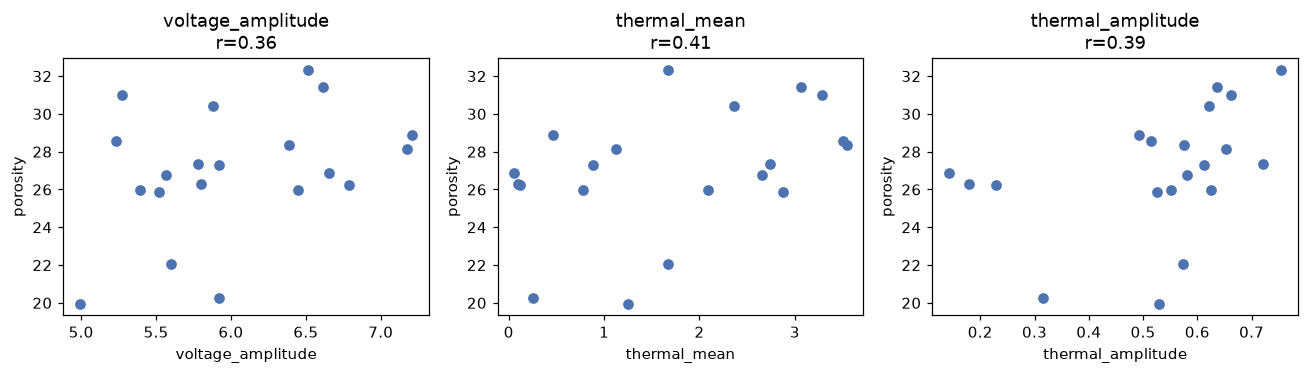

In [12]:
meas_eng = pd.DataFrame({"sample_id": meas["sample_id"]})
meas_eng["voltage_amplitude"] = (meas[vt_cols].max(axis=1) - meas[vt_cols].min(axis=1)) / 2.0
meas_eng["thermal_mean"] = meas[ir_cols].mean(axis=1)
meas_eng["thermal_amplitude"] = meas[ir_cols].std(axis=1)

sample_eng = meas_eng.groupby("sample_id").mean().reset_index()
sample_eng = sample_eng.merge(data[["sample_id", "porosity"]], on="sample_id").sort_values("sample_id").reset_index(drop=True)

eng_feats = ["voltage_amplitude", "thermal_mean", "thermal_amplitude"]
print("Pearson correlation with porosity (n=20):")
for feat in eng_feats:
    r, p = pearsonr(sample_eng[feat], sample_eng["porosity"])
    print(f"  {feat:20s} r={r:+.3f}  p={p:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, feat in zip(axes, eng_feats):
    ax.scatter(sample_eng[feat], sample_eng["porosity"], color="#4C72B0")
    r, _ = pearsonr(sample_eng[feat], sample_eng["porosity"])
    ax.set_title(f"{feat}\nr={r:.2f}")
    ax.set_xlabel(feat)
    ax.set_ylabel("porosity")
plt.tight_layout()
plt.show()


In [13]:
X3 = sample_eng[eng_feats].values

def evaluate_ols(X, y, scheme):
    cv = (KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) if scheme == "five_fold"
          else LeaveOneOut())
    preds = np.zeros(len(y))
    for train_idx, test_idx in cv.split(X):
        pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
        pipe.fit(X[train_idx], y[train_idx])
        preds[test_idx] = pipe.predict(X[test_idx])
    return mean_absolute_error(y, preds), preds

pass3_rows = []
for scheme in ["five_fold", "loo"]:
    for model_name in ["baseline", "ridge"]:
        mae, _ = evaluate(X3, y, scheme, model_name)
        pass3_rows.append({"scheme": scheme, "model": model_name, "MAE": round(mae, 3)})
    mae_ols, _ = evaluate_ols(X3, y, scheme)
    pass3_rows.append({"scheme": scheme, "model": "ols", "MAE": round(mae_ols, 3)})

pass3_table = pd.DataFrame(pass3_rows).pivot(index="model", columns="scheme", values="MAE")
pass3_table = pass3_table.reindex(["baseline", "ridge", "ols"])[["five_fold", "loo"]]
pass3_table


scheme,five_fold,loo
model,,
baseline,2.445,2.503
ridge,2.564,2.398
ols,2.571,2.316


The 3 engineered features show the strongest descriptive correlations of anything tried
(`thermal_mean` r≈0.41), but that doesn't fully translate into a consistent CV win: OLS and
ridge beat baseline under LOO, but not under 5-fold. By the same both-schemes-must-agree
rule applied everywhere above, **this is still an inconclusive result** — a more promising
one than Pass 1/2, and worth the follow-up recommended in Section 11, but not a confirmed
predictive relationship on 20 samples.

**Multiple-comparisons caveat, applying to everything above:** across Passes 1-3, roughly
10+ feature-set/model combinations were evaluated (full set x 2 models, 4 blocks x 2 models,
engineered set x 2 models, each x 2 CV schemes). With n=20, finding *some* configuration
that looks good by chance is the statistically expected outcome of trying that many
combinations, not proof of a real effect on its own. `IR_pix`/thermal features are flagged
as the most promising lead *because* they succeeded on two independent tests (Section 7's
per-block CV and Section 9's descriptive correlation), not because any single number looked
good.


## 10. Residual analysis (best configuration: ridge on `IR_pix`, 5-fold)

Looking at which samples drive the error for the single best-performing configuration
found — to check whether a few outlier samples are responsible for most of the miss, the
way samples 0 and 14 were checked in the original data-quality audit.


In [14]:
ir_mae, ir_preds = evaluate(data[ir_cols].values, y, "five_fold", "ridge")
resid_df = pd.DataFrame({
    "sample_id": data.sample_id,
    "porosity": y,
    "predicted": ir_preds.round(2),
    "abs_error": np.abs(ir_preds - y).round(2),
}).sort_values("abs_error", ascending=False).reset_index(drop=True)

print(f"IR_pix / ridge / 5-fold MAE = {ir_mae:.3f}  (baseline = {pass1_table.loc['baseline','five_fold']:.3f})")
resid_df


IR_pix / ridge / 5-fold MAE = 2.312  (baseline = 2.445)


,sample_id,porosity,predicted,abs_error
0,2,20.26,25.65,5.39
1,5,28.34,32.17,3.83
2,0,27.36,31.02,3.66
3,10,30.40,26.83,3.57
4,18,22.05,25.42,3.37
5,9,19.96,23.26,3.30
6,16,32.34,29.18,3.16
7,14,26.31,23.20,3.11
8,1,26.89,23.81,3.08
9,19,31.45,28.79,2.66


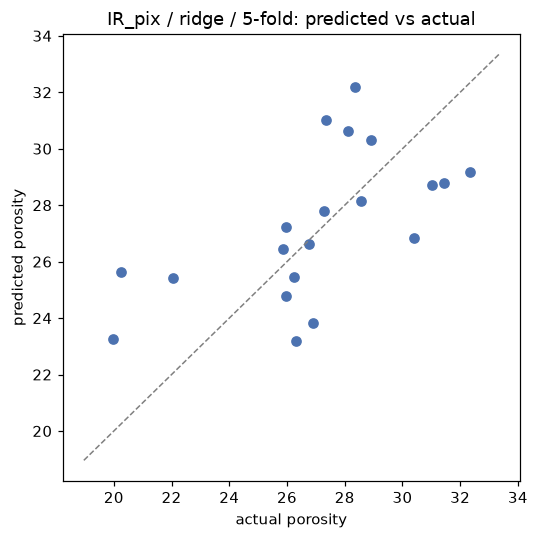

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y, ir_preds, color="#4C72B0")
lims = [min(y.min(), ir_preds.min()) - 1, max(y.max(), ir_preds.max()) + 1]
ax.plot(lims, lims, "--", color="gray", linewidth=1)
ax.set_xlabel("actual porosity")
ax.set_ylabel("predicted porosity")
ax.set_title("IR_pix / ridge / 5-fold: predicted vs actual")
plt.tight_layout()
plt.show()


Errors are spread across several samples rather than concentrated in one or two clear
outliers — there's no single sample whose removal would obviously "fix" the fit, which is
a mild point in favor of the thermal signal being a real, if weak and noisy, relationship
rather than an artifact of one unusual sample.


## 11. Conclusions and recommendations

**Bottom line for a customer conversation:** on this 20-sample dataset, no sensor
combination reliably beats a constant-porosity baseline across both validation schemes.
The one consistent, physically-interpretable lead is the **thermal image signal**
(`IR_pix` block, and the `thermal_mean`/`thermal_amplitude` summary features derived from
it) — it's the only configuration that beat baseline in every check it passed, and it has
a plausible physical story (process heat / thermal contrast relating to how the material
consolidates and therefore its porosity). That's a real result worth reporting honestly:
**not proof that porosity is predictable from these sensors, but a specific, falsifiable
hypothesis for a next round of data collection.**

**What would raise confidence, roughly in priority order:**
1. **More samples.** n=20 is the single biggest limiter on everything in this notebook —
   every "beats baseline" claim above is one or two prediction errors away from flipping.
   Even 40-60 samples would materially change how much these results can be trusted.
2. **Replicate measurements to quantify the noise floor**, particularly for `IR_pix`
   (thermal amplitude) and `V_t` (voltage amplitude) — knowing measurement-to-measurement
   noise vs. sample-to-sample variation would clarify how much of the observed correlation
   is signal vs. instrument/process noise.
3. **Validate the thermal lead on new samples**, since the 3 engineered features in Pass 3
   were chosen using the same 20 samples they're evaluated on (a well-motivated hypothesis
   test, not independent confirmation — see Section 9's caveat).
4. **Confirm the `V_t`/`I_t` time-axis assumption** (Section 8) with the data source —
   this notebook infers it from array shape and waveform appearance, not from an explicit
   timestamp column.


## 12. Assumptions and scope

- `V_t_0..511` / `I_t_0..511` are treated as a within-measurement time series (Section 8);
  not confirmed against a timestamp column, since none was provided.
- Each sample's 100 repeat measurements are aggregated by simple mean before modeling
  (Section 3). Sample-level median or trimmed mean were not explored; given the low
  within-sample CV found in Section 2, this is not expected to change conclusions.
- No samples or measurements were excluded — the data quality audit (Section 2) found no
  defect that would justify dropping any record.
- `thickness` is included as a candidate feature alongside the sensor blocks in Section 4's
  correlation check, but was not separately re-tested combined with the winning `IR_pix`
  features — a natural next step given more time, not included here to keep the analysis
  within scope.
